<a href="https://colab.research.google.com/github/JAYMAN735/ML-Projects/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd

In [ ]:
df = sns.load_dataset('mpg')

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


###Data Cleaning

In [ ]:
df['displacement_liters'] = df['displacement'] * 0.0163871
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,displacement_liters
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,5.030840
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,5.735485
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,5.211098
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,4.981678
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,4.948904


In [ ]:
df['displacement_liters'] = pd.to_numeric(df['displacement_liters'])
df['displacement_liters'] = df['displacement_liters'].map('{:.2f}L'.format)
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,displacement_liters
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,5.03L
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,5.74L
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,5.21L
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,4.98L
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,4.95L


In [ ]:
df = df.drop(columns=['displacement'])
df.head()

,mpg,cylinders,horsepower,weight,acceleration,model_year,origin,name,displacement_liters
0,18.0,8,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,5.03L
1,15.0,8,165.0,3693,11.5,70,usa,buick skylark 320,5.74L
2,18.0,8,150.0,3436,11.0,70,usa,plymouth satellite,5.21L
3,16.0,8,150.0,3433,12.0,70,usa,amc rebel sst,4.98L
4,17.0,8,140.0,3449,10.5,70,usa,ford torino,4.95L


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mpg                  398 non-null    float64
 1   cylinders            398 non-null    int64  
 2   horsepower           392 non-null    float64
 3   weight               398 non-null    int64  
 4   acceleration         398 non-null    float64
 5   model_year           398 non-null    int64  
 6   origin               398 non-null    object 
 7   name                 398 non-null    object 
 8   displacement_liters  398 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 28.1+ KB


###Statistics of Data

In [ ]:
df.describe()

,mpg,cylinders,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,230.000000,5140.000000,24.800000,82.000000


###Display null values from each column

In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0
displacement_liters,0


###Correlation matrix

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,mpg,cylinders,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.842983,0.896017,-0.505419,-0.348746
horsepower,-0.778427,0.842983,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.416361,-0.306564,0.288137,1.000000


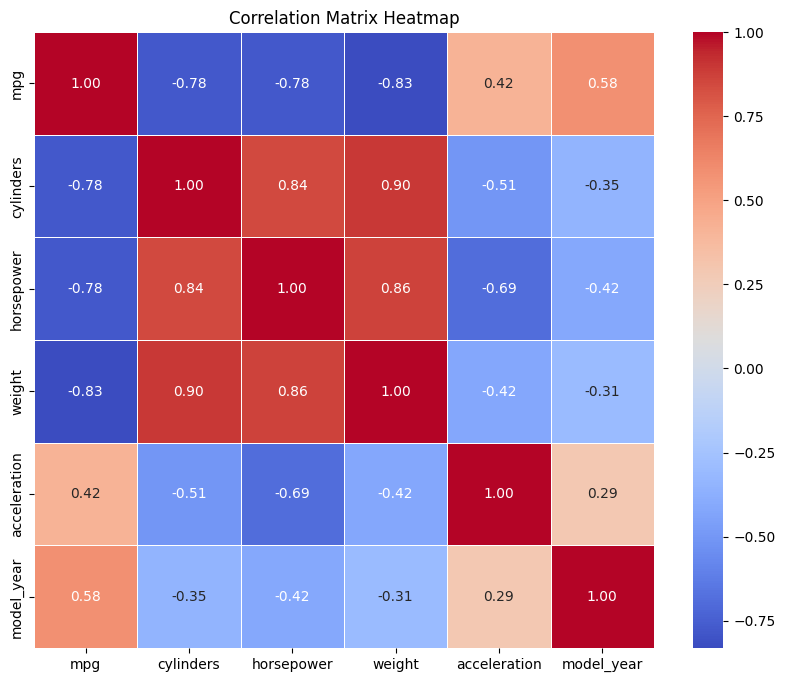

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

###Number of Cars by Origin

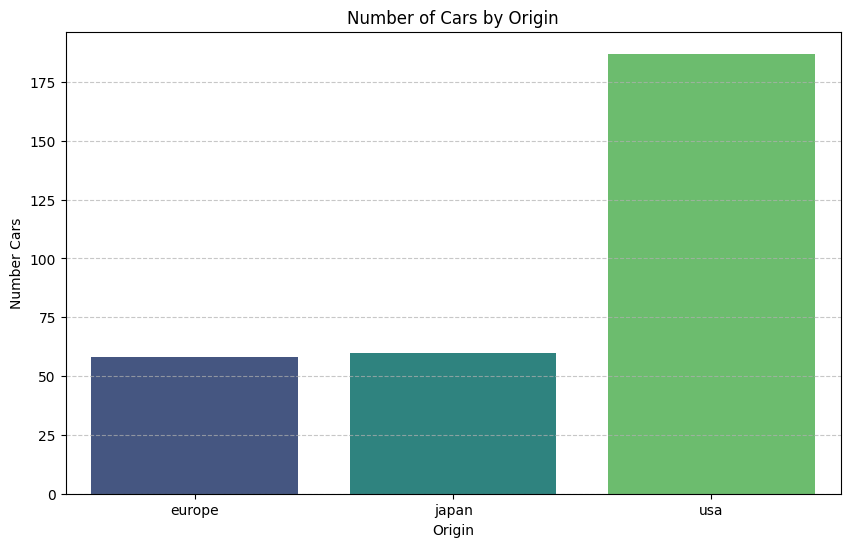

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count unique car names per origin
origin_name_counts = df.groupby('origin')['name'].nunique().reset_index(name='unique_name_count')

plt.figure(figsize=(10, 6))
sns.barplot(x='origin', y='unique_name_count', data=origin_name_counts, palette='viridis', hue='origin', legend=False)
plt.title('Number of Cars by Origin')
plt.xlabel('Origin')
plt.ylabel('Number Cars')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

###Visualization of numerical columns

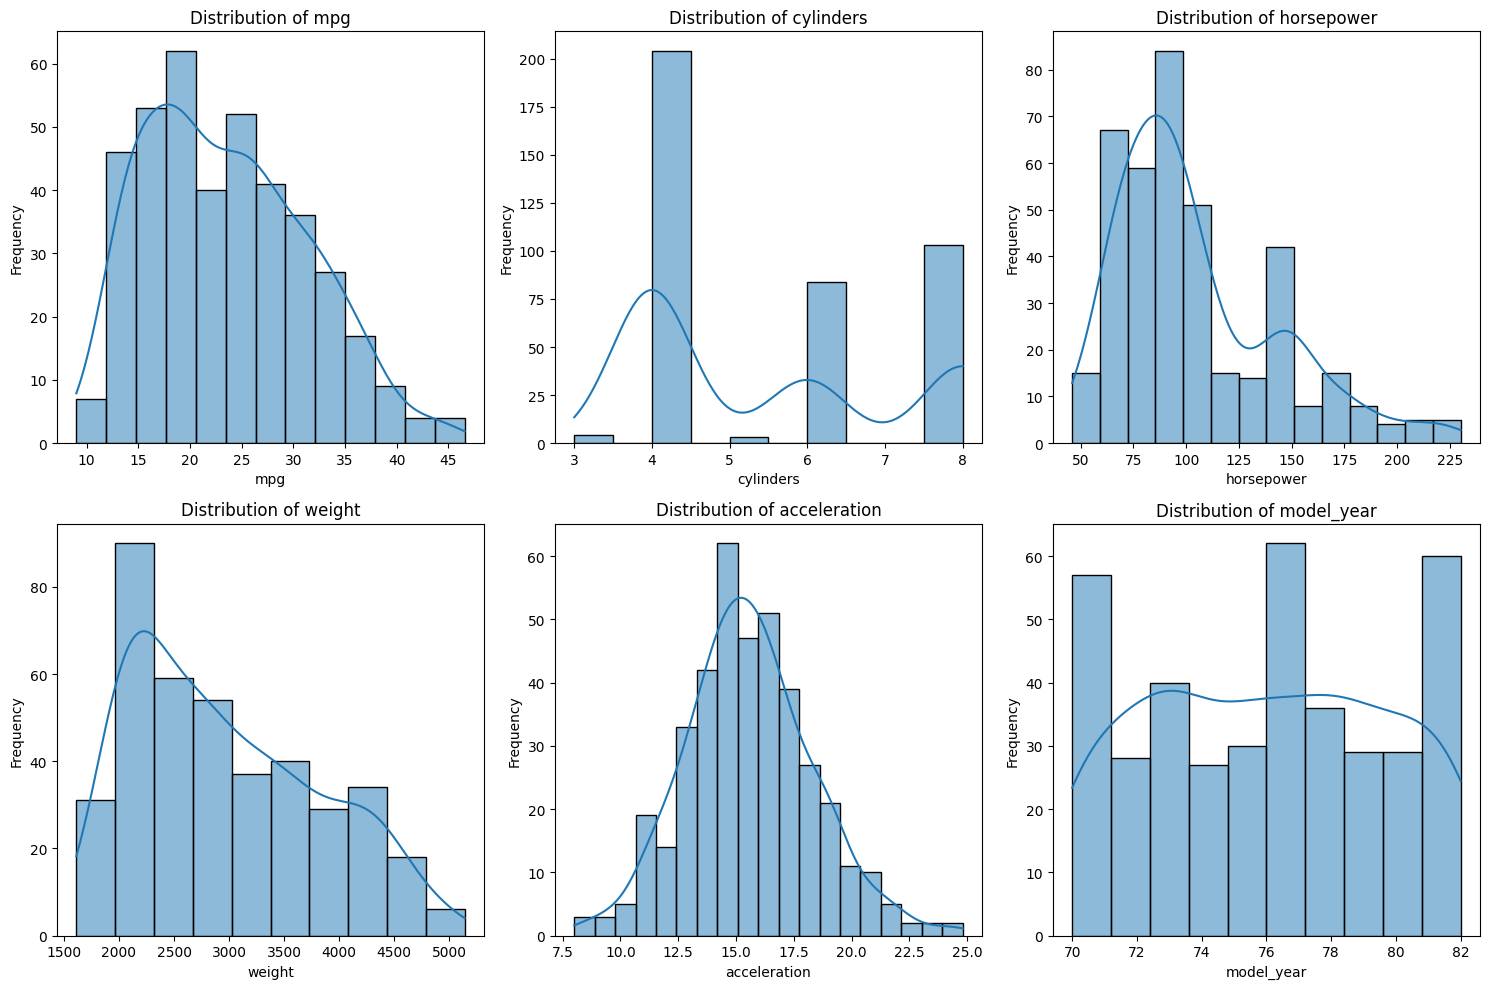

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to visualize
numerical_cols = ['mpg', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.histplot(df[col].dropna(), kde=True) # dropna() to handle potential NaN values in horsepower
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

###Scatter plot to visualize the relationship between horsepower and acceleration

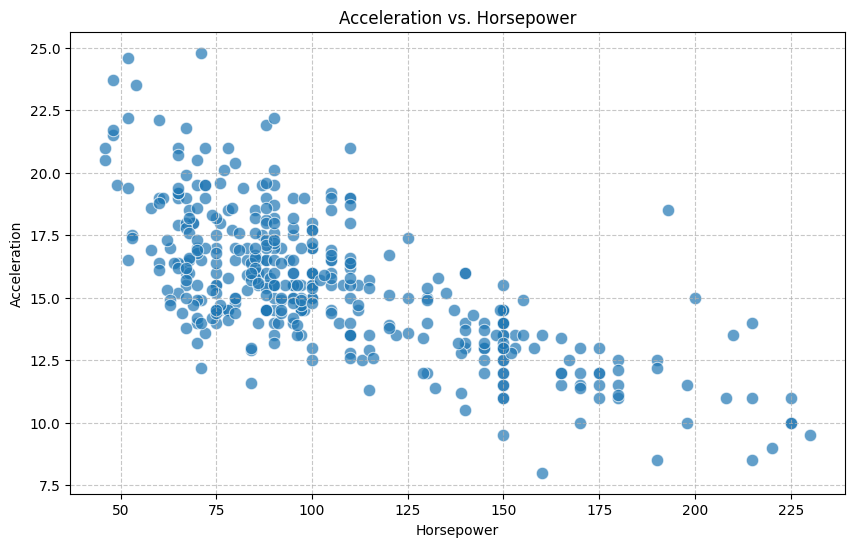

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='acceleration', data=df, s=80, alpha=0.7)
plt.title('Acceleration vs. Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Acceleration')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

###List of features to plot against mpg

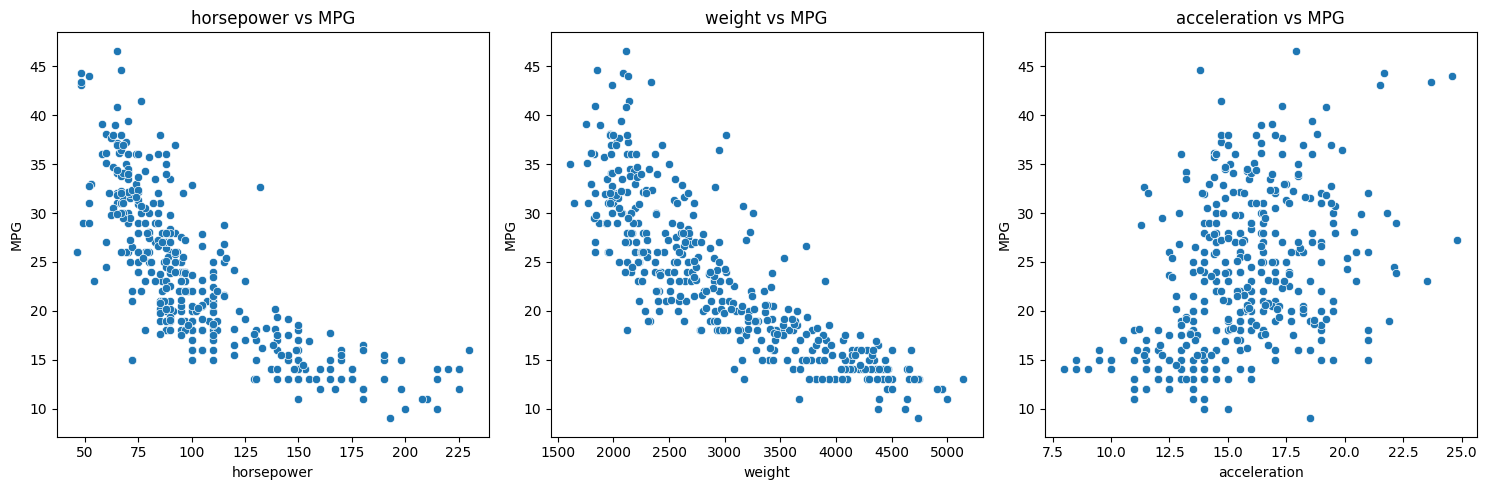

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features to plot against mpg
features_for_scatter = ['horsepower', 'weight', 'acceleration']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_for_scatter):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=df[col], y=df['mpg'])
    plt.title(f'{col} vs MPG')
    plt.xlabel(col)
    plt.ylabel('MPG')

plt.tight_layout()
plt.show()

###List of Cars based on highest displacement_liters

In [ ]:
# Convert 'displacement_liters' to numeric for sorting
df['displacement_liters_numeric'] = df['displacement_liters'].str.replace('L', '').astype(float)

# Sort by 'displacement_liters' in descending order and select 'name' and 'displacement_liters'
sorted_cars_by_displacement = df.sort_values(by='displacement_liters_numeric', ascending=False)[['name', 'displacement_liters']]

display(sorted_cars_by_displacement.head())

# Drop the temporary numeric column
df = df.drop(columns=['displacement_liters_numeric'])

,name,displacement_liters
8,pontiac catalina,7.46L
13,buick estate wagon (sw),7.46L
95,buick electra 225 custom,7.46L
6,chevrolet impala,7.44L
7,plymouth fury iii,7.21L


###List of Cars Based on Horsepower

In [ ]:
# Sort by 'horsepower' in descending order and select 'name' and 'horsepower'
top_10_horsepower_cars = df.sort_values(by='horsepower', ascending=False)[['name', 'horsepower']]

display(top_10_horsepower_cars.head(10))

,name,horsepower
116,pontiac grand prix,230.0
95,buick electra 225 custom,225.0
8,pontiac catalina,225.0
13,buick estate wagon (sw),225.0
6,chevrolet impala,220.0
94,chrysler new yorker brougham,215.0
25,ford f250,215.0
7,plymouth fury iii,215.0
27,dodge d200,210.0
67,mercury marquis,208.0


###Average MPG by Origin and Cylinders

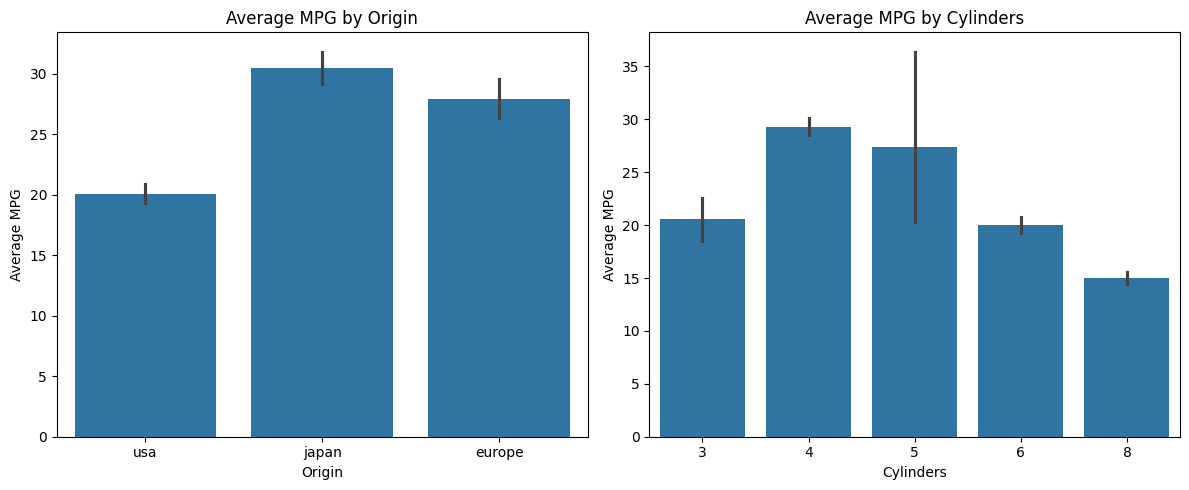

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average MPG by Origin
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='origin', y='mpg', data=df)
plt.title('Average MPG by Origin')
plt.xlabel('Origin')
plt.ylabel('Average MPG')

# Average MPG by Cylinders
plt.subplot(1, 2, 2)
sns.barplot(x='cylinders', y='mpg', data=df)
plt.title('Average MPG by Cylinders')
plt.xlabel('Cylinders')
plt.ylabel('Average MPG')

plt.tight_layout()
plt.show()